In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import sys
sys.path.insert(0, "../../src")

import gc
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.distributed as dist
import zarr as z

from juart.conopt.functional.fourier import (
    fourier_transform_adjoint,
    fourier_transform_forward,
    nonuniform_fourier_transform_adjoint,
)
from juart.conopt.tfs.fourier import nonuniform_transfer_function
from juart.dl.checkpoint.manager import CheckpointManager
from juart.dl.loss.loss import JointLoss
from juart.dl.model.unrollnet import (
    LookaheadModel,
    UnrolledNet,
)
from juart.dl.operation.modules import training, validation
from juart.dl.utils.dist import GradientAccumulator
from juart.vis.interactive import InteractiveFigure3D, InteractiveMultiPlotter3D

In [2]:
data_path = "/home/jovyan/juart/examples/data/kooshball_GRE_1000spk_preproc.h5"

with h5py.File(data_path, "r") as f:

    print(f.keys())
    
    k = torch.from_numpy(f['traj'][:])[...,None]
    C = torch.from_numpy(f['sens_maps'][:])
    d = torch.from_numpy(f['data_comp'][:])[...,None]
    cc = f["cc_matrix"]

    print(f"Coilsensitivity shape {C.shape}")
    print(f"Trajectory shape {k.shape}")
    print(f"Signal shape {d.shape}")
    print(f"cc shape: {cc.shape}")

k /= (2*k.max())

<KeysViewHDF5 ['cc_matrix', 'data_comp', 'sens_maps', 'traj']>
Coilsensitivity shape torch.Size([12, 128, 128, 128])
Trajectory shape torch.Size([3, 128, 900, 1])
Signal shape torch.Size([12, 128, 900, 1])
cc shape: (1, 1, 1, 52, 52)


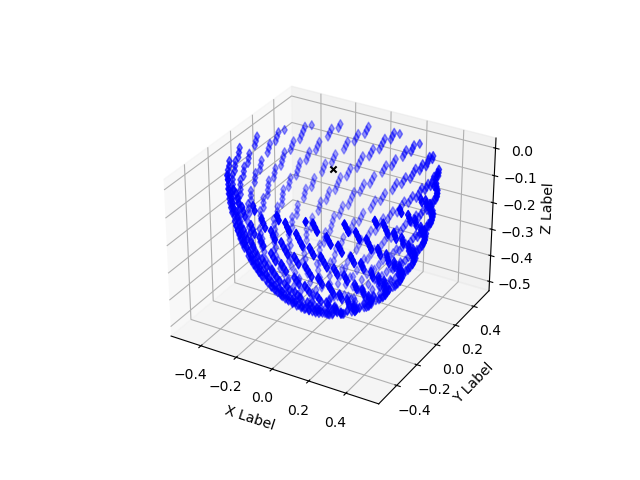

In [3]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection='3d')

x1 = k[0,0:1,:,0]
y1 = k[1,0:1,:,0]
z1 = k[2,0:1,:,0]

ax1.scatter(x1, y1, z1, c='b', marker='d')
ax1.scatter(0,0,0,c="k",marker="x")

ax1.set_xlabel('X Label')
ax1.set_ylabel('Y Label')
ax1.set_zlabel('Z Label')

plt.show()

torch.Size([3, 115200, 1])


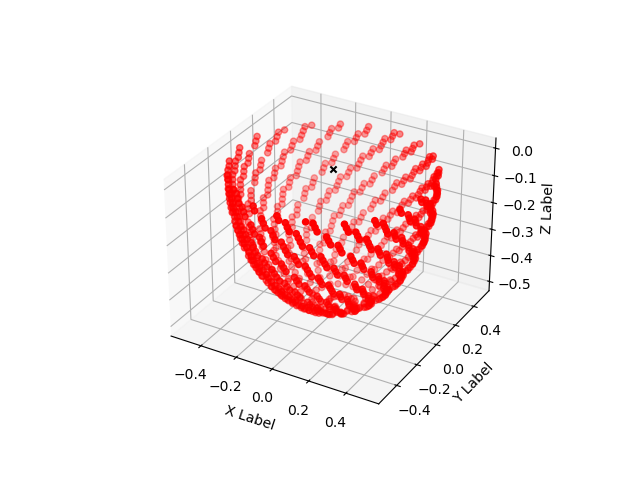

In [4]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection='3d')

k_test = k.reshape((3,k.shape[1]*k.shape[2],1))
print(k_test.shape)

x2 = k_test[0,:900,0]
y2 = k_test[1,:900,0]
z2 = k_test[2,:900,0]

ax2.scatter(x2, y2, z2, c='r', marker='o')
ax2.scatter(0,0,0,c="k",marker="x")

ax2.set_xlabel('X Label')
ax2.set_ylabel('Y Label')
ax2.set_zlabel('Z Label')

plt.show()

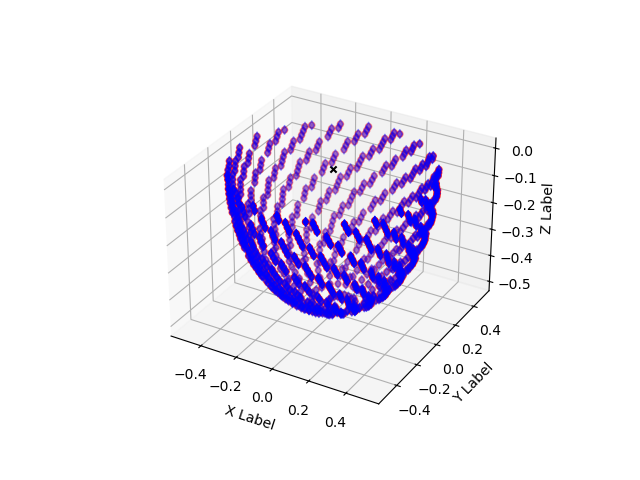

In [5]:
fig3 = plt.figure()
ax3 = fig3.add_subplot(111, projection='3d')

ax3.scatter(x2, y2, z2, c='r', marker='o')
ax3.scatter(x1, y1, z1, c='b', marker='d')
ax3.scatter(0,0,0,c="k",marker="x")

ax3.set_xlabel('X Label')
ax3.set_ylabel('Y Label')
ax3.set_zlabel('Z Label')

plt.show()

interactive(children=(IntSlider(value=64, description='Dimension 3:', max=128, min=1), Output()), _dom_classes…

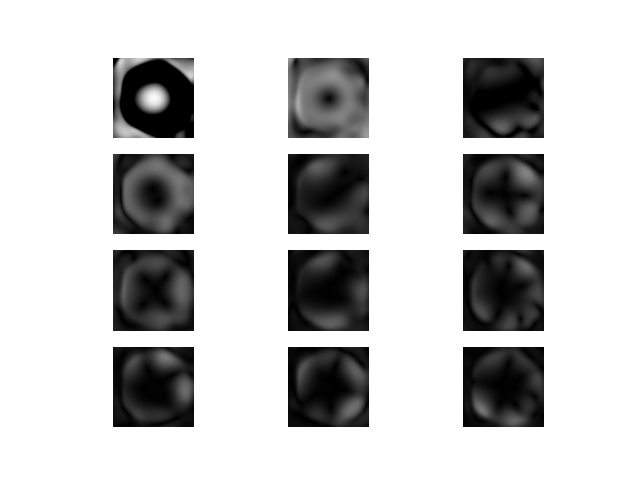

In [15]:
coil_list = []
for coil in C:
    coil_list.append(coil.abs())

InteractiveMultiPlotter3D(coil_list,
                          layout = [4,3],
                          cmap="gray",
                          vmax = 1,
                          compact_plotting = False,
                          show_axis = False,
                          activate_colorbar = False).interactive